# XGBOOST

Debido a la falta de precisión de Random Forest, vamos a crear un modelo XGBoost para poder contrastar y darle al departamento de RRHH una mayor visión sobre el estado de los empleados para poder tomar una mejor decisión.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


## Carga del Dataset

In [2]:
df = pd.read_csv('../data/raw/EmployeeAttrition.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Vamos a realizar el mismo tratamiento de los datos que con el modelo Random Forest, utilizamos Label Encoding para variables binarias (Si o No), y One-Hot Encoding para el resto de columnas no numéricas.

In [3]:
#Eliminar columnas innecesarias
try:
    cols_to_drop = ['Over18', 'StandardHours', 'EmployeeCount', 'JobLevel']
    df = df.drop(columns=cols_to_drop)

except:
    print(df.head())
# Label Encoding para binarias (incluyendo Attrition)
le = LabelEncoder()
binarias = ['Attrition', 'OverTime', 'Gender']
for col in binarias:
    df[col] = le.fit_transform(df[col])

# One-Hot Encoding para las demás (Nominales)
df = pd.get_dummies(df, columns=['BusinessTravel', 'Department', 'EducationField', 
                                 'JobRole', 'MaritalStatus'], drop_first=True)

In [4]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

ratio_desbalanceo = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = XGBClassifier(
    n_estimators=100,          
    learning_rate=0.3,         
    max_depth=2,
    device='cuda',        # Comentar esta linea para usar la CPU en lugar de la GPU       
    scale_pos_weight=ratio_desbalanceo, 
    eval_metric='logloss',
    random_state=2
)
print("Ratio desbalanceo: ",ratio_desbalanceo)

# Entrenamos el modelo
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred = xgb_model.predict(X_test)

# Evaluamos
print(classification_report(y_test, y_pred))

Ratio desbalanceo:  5.189473684210526
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       247
           1       0.51      0.64      0.57        47

    accuracy                           0.84       294
   macro avg       0.72      0.76      0.74       294
weighted avg       0.86      0.84      0.85       294



d:\Master\TFM\TFMDataScience\.venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [12:20:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Internamente, XGBoost calcula una función de pérdida (loss function) en cada paso. Si no usas scale_pos_weight, un fallo en la clase 0 (quedarse) y un fallo en la clase 1 (irse) valen lo mismo: 1.

Al pasarle tu ratio_desbalanceo (que con tus números da aproximadamente 5.25), la matemática cambia así:

Error al predecir la clase 0: penalización de 1.

Error al predecir la clase 1: penalización de 5.25.

El algoritmo se vuelve "cinco veces más sensible" a los empleados que se van, lo que empuja a los árboles de decisión a buscar patrones de burnout, sueldo o distancia a casa que expliquen esa clase minoritaria.

Un apunte crucial según tus métricas anteriores
Si en la captura que me pasaste antes (donde tenías un Recall de 0.43 para la clase 1) YA estabas usando este ratio, significa una de estas dos cosas:

Falta de hiperparámetros: XGBoost es muy potente pero se sobreajusta rápido. Si max_depth es muy alto o learning_rate no está fino, el peso no hará milagros.

Falta de "señal" en los datos (Feature Engineering): Puede que las variables actuales no tengan suficiente fuerza para explicar el burnout. Necesitáis crear variables nuevas combinando las existentes (por ejemplo: Aumento_Sueldo_Por_Año = PercentSalaryHike / YearsAtCompany).

Si por el contrario, en la captura anterior AÚN NO habías aplicado el scale_pos_weight, vuelve a entrenar el modelo ahora mismo con ese cambio. Verás cómo ese 0.43 del Recall sube notablemente.

## Optimización de Hiperparámetros

Vamos a realizar una serie de ajustes al modelo para comparar y ver si podemos mejorar las métricas. La prioridad siempre va a ser sacrificar Precision por Recall en caso de ser necesario, ya que para RRHH, el coste de un falso positivo siempre será menor que tener que reemplazar a una persona que se ha ido y no queríamos que se fuera.

In [5]:
import subprocess
import xgboost

try:
    cmd = "nvidia-smi --query-gpu=gpu_name --format=csv,noheader"
    gpu_name = subprocess.check_output(cmd, shell=True).decode('utf-8').strip()
    print(f"🚀 CUDA está configurado con el dispositivo: {gpu_name}")
except Exception:
    print("❌ No se pudo identificar el nombre de la GPU mediante nvidia-smi.")


build_info = xgboost.core.build_info()

print(build_info)


🚀 CUDA está configurado con el dispositivo: NVIDIA GeForce RTX 4070
{'BUILTIN_PREFETCH_PRESENT': False, 'CUDA_VERSION': [12, 9], 'DEBUG': False, 'MM_PREFETCH_PRESENT': True, 'THRUST_VERSION': [2, 8, 2], 'USE_CUDA': True, 'USE_DLOPEN_NCCL': False, 'USE_FEDERATED': False, 'USE_NCCL': False, 'USE_NVCOMP': False, 'USE_OPENMP': True, 'USE_RMM': False, 'libxgboost': 'd:\\Master\\TFM\\TFMDataScience\\.venv\\Lib\\site-packages\\xgboost\\lib\\xgboost.dll'}


In [6]:
# Vamos a probar a reaujastar el learning_rate, poniendolo mas bajo y aumentando el numero de arboles

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2, stratify=y)

ratio_desbalanceo = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_model = XGBClassifier(
    n_estimators=10000,          
    learning_rate=0.01,         
    max_depth=2,  
    device='cuda',  # Comentar esta linea para usar la CPU en lugar de la GPU            
    scale_pos_weight=ratio_desbalanceo, 
    eval_metric='logloss',
    random_state=2
)
print("Ratio desbalanceo: ",ratio_desbalanceo)

# Entrenamos el modelo
xgb_model.fit(X_train, y_train)

# Predicciones
y_pred = xgb_model.predict(X_test)

# Evaluamos
print(classification_report(y_test, y_pred))

Ratio desbalanceo:  5.198795180722891
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       370
           1       0.54      0.55      0.55        71

    accuracy                           0.85       441
   macro avg       0.73      0.73      0.73       441
weighted avg       0.85      0.85      0.85       441



In [24]:
# 1. Definimos los cortes de la pirámide basados en las probabilidades
limites = [0, 0.32, 0.70, 1.0]
nombres_niveles = ['3. Base (Bajo Riesgo)', '2. Cuerpo (Riesgo Moderado)', '1. Vértice (Riesgo Crítico)']

probabilidades = xgb_model.predict_proba(X)[:, 1]
df_resultados = pd.DataFrame(index=X.index)

df_resultados['EmployeeNumber'] = df.loc[X.index, 'EmployeeNumber']
df_resultados['Probabilidad_Fuga'] = probabilidades
#df_resultados['Prediccion_Alarma'] = y_pred_personalizado
# 2. Creamos la columna del nivel en nuestro dataframe de resultados
df_resultados['Nivel_Piramide'] = pd.cut(df_resultados['Probabilidad_Fuga'], 
                                         bins=limites, 
                                         labels=nombres_niveles, 
                                         include_lowest=True)

# 3. Unimos los datos originales (características) para poder analizarlos por grupo
df_analisis = df_resultados.join(df[['YearsAtCompany', 'MonthlyIncome', 'PercentSalaryHike', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement']])

# 4. Contamos cuántos empleados hay en cada escalón de la pirámide
print("--- DISTRIBUCIÓN DE LA PIRÁMIDE ---")
print(df_analisis['Nivel_Piramide'].value_counts().sort_index())
print("\n")

# 5. PERFILADO: Sacamos las características medias de cada grupo
print("--- CARACTERÍSTICAS MEDIAS POR NIVEL ---")
perfil_grupos = df_analisis.groupby('Nivel_Piramide', observed=False)[['Probabilidad_Fuga', 'YearsAtCompany', 'MonthlyIncome', 'PercentSalaryHike', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement']].mean()
print(perfil_grupos)


--- DISTRIBUCIÓN DE LA PIRÁMIDE ---
Nivel_Piramide
3. Base (Bajo Riesgo)          1187
2. Cuerpo (Riesgo Moderado)      71
1. Vértice (Riesgo Crítico)     212
Name: count, dtype: int64


--- CARACTERÍSTICAS MEDIAS POR NIVEL ---
                             Probabilidad_Fuga  YearsAtCompany  MonthlyIncome  \
Nivel_Piramide                                                                  
3. Base (Bajo Riesgo)                 0.055604        7.550969    6948.747262   
2. Cuerpo (Riesgo Moderado)           0.482712        5.436620    5271.014085   
1. Vértice (Riesgo Crítico)           0.931195        4.495283    4419.358491   

                             PercentSalaryHike  DistanceFromHome  Education  \
Nivel_Piramide                                                                
3. Base (Bajo Riesgo)                15.267902          8.825611   2.926706   
2. Cuerpo (Riesgo Moderado)          14.591549         10.971831   2.985915   
1. Vértice (Riesgo Crítico)          15.089623    

In [21]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,41,1,1102,1,2,1,2,0,94,3,...,False,False,False,False,False,False,True,False,False,True
1,49,0,279,8,1,2,3,1,61,2,...,False,False,False,False,False,True,False,False,True,False
2,37,1,1373,2,2,4,4,1,92,2,...,False,True,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,5,4,0,56,3,...,False,False,False,False,False,True,False,False,True,False
4,27,0,591,2,1,7,1,1,40,3,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,2061,3,1,41,4,...,False,True,False,False,False,False,False,False,True,False
1466,39,0,613,6,1,2062,4,1,42,2,...,False,False,False,False,False,False,False,False,True,False
1467,27,0,155,4,3,2064,2,1,87,4,...,False,False,False,True,False,False,False,False,True,False
1468,49,0,1023,2,3,2065,4,1,63,2,...,False,False,False,False,False,False,True,False,True,False


C:\Users\lamie\AppData\Local\Temp\ipykernel_19564\4116018398.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(x='Importancia', y='Variable', data=df_importances, palette='magma')


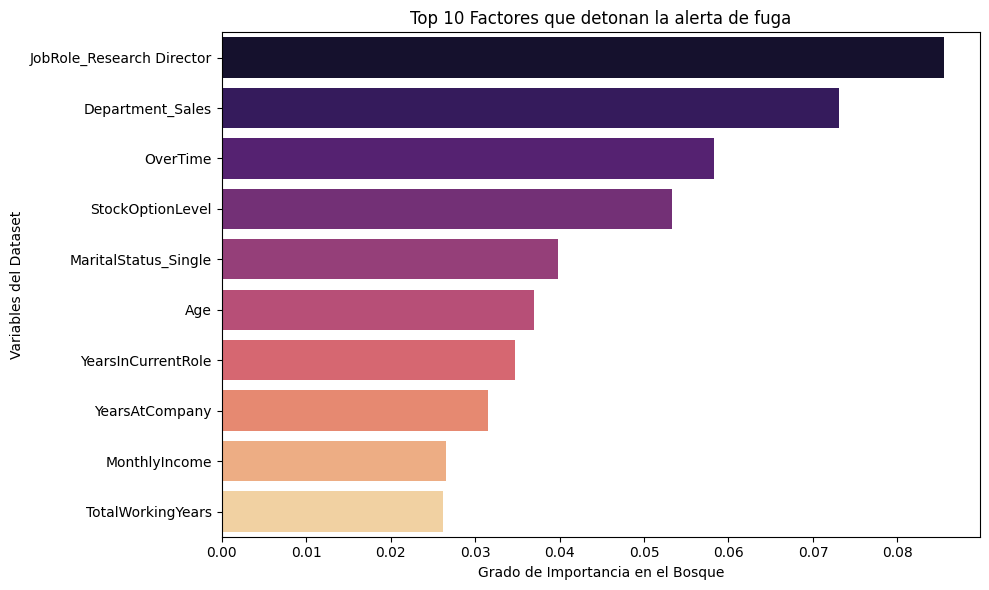

In [26]:
importances = xgb_model.feature_importances_
features = X.columns


df_importances = pd.DataFrame({'Variable': features, 'Importancia': importances})
df_importances = df_importances.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sb.barplot(x='Importancia', y='Variable', data=df_importances, palette='magma')
plt.title('Top 10 Factores que detonan la alerta de fuga')
plt.xlabel('Grado de Importancia en el Bosque')
plt.ylabel('Variables del Dataset')
plt.tight_layout()
plt.show()

En comparación a Random Forest, se puede apreciar que con XGBoost ha podido ver el patrón también del departamento, ya que la mayoría de los empleados que se van son del departamento de ventas

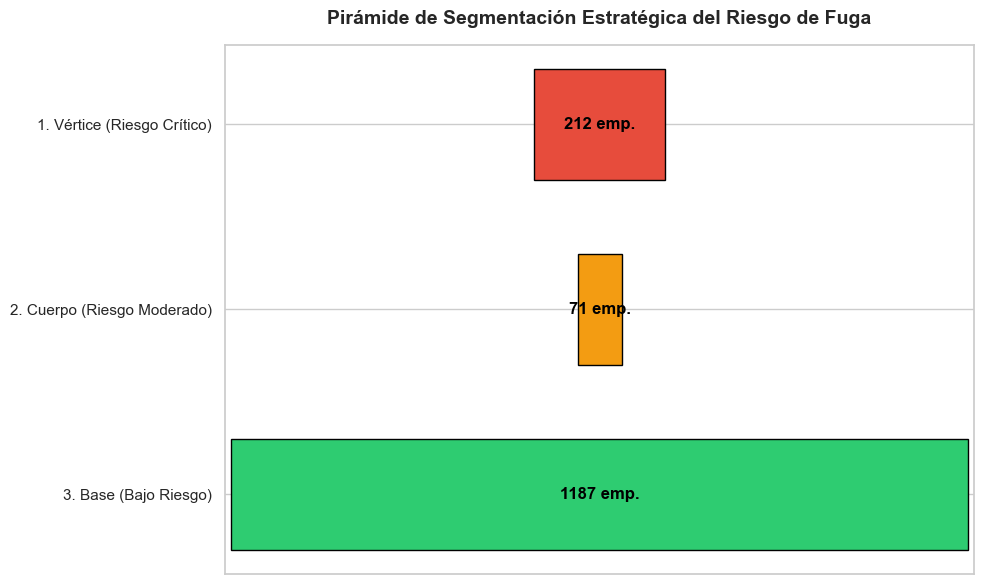

In [31]:
# 1. Contamos cuántos empleados hay por nivel y ordenamos de la Base al Vértice
conteos = df_analisis['Nivel_Piramide'].value_counts().sort_index(ascending=True)

# Para simular una pirámide simétrica, calculamos posiciones centradas en el eje Y
niveles = conteos.index
valores = conteos.values
max_val = max(valores)

# Configuración del gráfico
plt.figure(figsize=(10, 6))
sb.set_theme(style="whitegrid")

# Dibujamos las barras centrándolas artificialmente
# El truco está en que el inicio de la barra (left) se desplaza para que queden alineadas al centro
left_coords = (max_val - valores) / 2
colores = ['#2ecc71', '#f39c12', '#e74c3c'] # Rojo (Crítico), Naranja (Moderado), Verde (Bajo)

bars = plt.barh(niveles, valores, left=left_coords, color=colores, edgecolor='black', height=0.6)

# Añadir las etiquetas con el número exacto de empleados dentro o sobre las barras
for bar, val in zip(bars, valores):
    x_pos = bar.get_x() + bar.get_width() / 2
    y_pos = bar.get_y() + bar.get_height() / 2
    plt.text(x_pos, y_pos, f'{val} emp.', 
             va='center', ha='center', color='black', fontweight='bold', fontsize=12)

plt.title('Pirámide de Segmentación Estratégica del Riesgo de Fuga', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Volumen de Empleados (Centrado)', fontsize=11)
plt.xlim(-10, max_val + 10) # Margen dinámico
plt.gca().axes.get_xaxis().set_visible(False) # Ocultamos el eje X numérico ya que está descentrado

plt.tight_layout()
plt.show()